In [30]:
import pandas as pd

# Load your file
df = pd.read_excel("data_202204_202503.xlsx")

# Convert YM (e.g. 202204) → proper monthly date (YYYY-MM-01)
df['Month'] = pd.to_datetime(df['YM'].astype(str) + '01', format='%Y%m%d')
df['Month'] = df['Month'].dt.normalize()


# Aggregate by Product & Month
monthly_df = (
    df.groupby(['Month', 'Item Description'], as_index=False)
      .agg({
          'QTY': 'sum',        # total quantity per month per product
          'Rate': 'mean',      # average rate across purchases that month
          'Amount': 'sum'      # total purchase value that month
      })
)

# Rename for clarity
monthly_df.rename(columns={
    'Item Description': 'Product_Name',
    'QTY': 'Quantity',
    'Rate': 'Avg_Rate'
}, inplace=True)

# Sort
monthly_df = monthly_df.sort_values(['Product_Name', 'Month'])

# Save this clean dataset (ready for forecasting)
monthly_df.to_excel("AV_monthly_clean.xlsx", index=False)
monthly_df['Month'] = monthly_df['Month'].dt.strftime('%Y-%m-%d')

print(" Aggregated monthly dataset ready: 'AV_monthly_clean.xlsx'")
monthly_df.head()


✅ Aggregated monthly dataset ready: 'AV_monthly_clean.xlsx'


,Month,Product_Name,Quantity,Avg_Rate,Amount
876,2022-06-01,018NW PROLENE JJ,12.0,170.8000,2049.60
5740,2023-04-01,018NW PROLENE JJ,50.0,151.7858,7589.29
6745,2023-06-01,0756 BIOS D5 BFS 500M,960.0,11.5500,11088.00
6746,2023-06-01,0756 BIOS DNS BFS 500,960.0,11.5500,11088.00
6747,2023-06-01,0756 BIOS NS BFS 500M,720.0,11.2000,8064.00


#### Filtering out data for AV Products from overall data

In [31]:
import pandas as pd



#  Load your AV items list
av_list_df = pd.read_excel("AV_Item_List.xlsx")

# Extract product names (remove extra spaces or casing differences)
av_items = av_list_df['AV Items'].astype(str).str.strip().str.upper().unique()

#  Standardize the Product_Name column in your main data (to match properly)
monthly_df['Product_Name'] = monthly_df['Product_Name'].astype(str).str.strip().str.upper()

# Filter only AV items
av_df = monthly_df[monthly_df['Product_Name'].isin(av_items)]

# Save the AV-only dataset
av_df.to_excel("AV_items_monthly.xlsx", index=False)

print("Filtered AV-only dataset saved as 'AV_items_monthly.xlsx'")
print(f"Total unique items after filter: {av_df['Product_Name'].nunique()}")
av_df.head()


✅ Filtered AV-only dataset saved as 'AV_items_monthly.xlsx'
Total unique items after filter: 58


,Month,Product_Name,Quantity,Avg_Rate,Amount
14,2022-04-01,ACCU CHEK ACTIVE,432.0,996.426667,309090.24
457,2022-05-01,ACCU CHEK ACTIVE,300.0,949.743333,253274.10
903,2022-06-01,ACCU CHEK ACTIVE,570.0,822.120000,415290.00
1791,2022-08-01,ACCU CHEK ACTIVE,420.0,694.120000,291530.40
2246,2022-09-01,ACCU CHEK ACTIVE,354.0,967.300000,326773.20


##### Adding 0 Months for the product when there was no order placed for them so that each product has 36 rows i.e 36 months

In [32]:
import pandas as pd
import numpy as np

# ---  Ensure Month is datetime (avoid warning with .loc) ---
av_df = av_df.copy()  # make a true copy to avoid SettingWithCopyWarning
av_df.loc[:, 'Month'] = pd.to_datetime(av_df['Month']).dt.to_period('M').dt.to_timestamp()

# ---  Load AV item list to preserve product order ---
av_list_df = pd.read_excel("AV_Item_List.xlsx")
av_items = av_list_df['AV Items'].astype(str).str.strip().str.upper().tolist()

# Normalize product names
av_df.loc[:, 'Product_Name'] = av_df['Product_Name'].astype(str).str.strip().str.upper()

# --- Check for duplicates ---
dups = av_df[av_df.duplicated(subset=['Month','Product_Name'], keep=False)].sort_values(['Product_Name','Month'])
if not dups.empty:
    print(f"⚠ Found {dups[['Month','Product_Name']].drop_duplicates().shape[0]} duplicate keys (multiple batches same month):")
    display(dups.head(10))
else:
    print("✅ No duplicate Month–Product pairs found.")

# --- Aggregate duplicates properly ---
av_agg = (
    av_df.groupby(['Month', 'Product_Name'], as_index=False)
         .agg({'Quantity': 'sum', 'Avg_Rate': 'mean', 'Amount': 'sum'})
)
# Weighted average rate if amount available
av_agg['Avg_Rate'] = av_agg.apply(
    lambda r: (r['Amount'] / r['Quantity']) if r['Quantity'] > 0 else r['Avg_Rate'],
    axis=1
)

# ---  Create complete Month × Product grid ---
all_months = pd.date_range(start=av_agg['Month'].min(), end=av_agg['Month'].max(), freq='MS')
full_index = pd.MultiIndex.from_product([all_months, av_items], names=['Month', 'Product_Name'])

av_full = av_agg.set_index(['Month','Product_Name']).reindex(full_index).reset_index()

# ---  Fill missing values ---
# Quantity = 0 means no orders that month
av_full['Quantity'] = av_full['Quantity'].fillna(0)

# Forward/backward fill Avg_Rate using transform (fixes your index error)
av_full['Avg_Rate'] = (
    av_full.groupby('Product_Name')['Avg_Rate']
           .transform(lambda x: x.ffill().bfill())
)

# Compute Amount again
av_full['Amount'] = av_full['Quantity'] * av_full['Avg_Rate']

# ---  Preserve AV list order ---
av_full['Product_Name'] = pd.Categorical(av_full['Product_Name'], categories=av_items, ordered=True)
av_full = av_full.sort_values(['Product_Name', 'Month']).reset_index(drop=True)

# ---  Save final clean dataset ---
av_full.to_excel("AV_monthly_full_with_zeroes_ordered.xlsx", index=False)

print(" Final clean file saved: 'AV_monthly_full_with_zeroes_ordered.xlsx'")
print(f"Products: {av_full['Product_Name'].nunique()} | Months: {av_full['Month'].nunique()}")
print("Sample (OMRON NEBULIZER):")
display(av_full[av_full['Product_Name'] == 'OMRON NEBULIZER'].head(12))


⚠ Found 1 duplicate keys (multiple batches same month):


,Month,Product_Name,Quantity,Avg_Rate,Amount
4081,2022-12-01 00:00:00,OMRON NEBULIZER,80.0,990.0,79200.0
4082,2022-12-01 00:00:00,OMRON NEBULIZER,18.0,1950.0,35100.0


✅ Final clean file saved: 'AV_monthly_full_with_zeroes_ordered.xlsx'
Products: 58 | Months: 36
Sample (OMRON NEBULIZER):


,Month,Product_Name,Quantity,Avg_Rate,Amount
576,2022-04-01,OMRON NEBULIZER,0.0,1026.790000,0.0
577,2022-05-01,OMRON NEBULIZER,0.0,1026.790000,0.0
578,2022-06-01,OMRON NEBULIZER,0.0,1026.790000,0.0
579,2022-07-01,OMRON NEBULIZER,0.0,1026.790000,0.0
580,2022-08-01,OMRON NEBULIZER,40.0,1026.790000,41071.6
581,2022-09-01,OMRON NEBULIZER,0.0,1026.790000,0.0
582,2022-10-01,OMRON NEBULIZER,0.0,1026.790000,0.0
583,2022-11-01,OMRON NEBULIZER,0.0,1026.790000,0.0
584,2022-12-01,OMRON NEBULIZER,98.0,1166.326531,114300.0
585,2023-01-01,OMRON NEBULIZER,0.0,1166.326531,0.0


##### Cross checking number of AV Items after deadling with 1 duplicate product

In [33]:
import pandas as pd

df = pd.read_excel("AV_monthly_full_with_zeroes_ordered.xlsx")

# Confirm unique product count
print("Unique products:", df['Product_Name'].nunique())

# Print missing products (if any) from AV list
av_list_df = pd.read_excel("AV_Item_List.xlsx")
av_items = av_list_df['AV Items'].astype(str).str.strip().str.upper().unique().tolist()

missing = [p for p in av_items if p not in df['Product_Name'].unique()]
print("Missing AV items:", missing)


Unique products: 58
Missing AV items: []


##### Creating Chart to Show Variability of Qty and Avg Rate along months for a Particular product

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import numpy as np

# Load the clean dataset (use correct path if needed)
df = pd.read_excel("AV_monthly_full_with_zeroes_ordered.xlsx")
df['Month'] = pd.to_datetime(df['Month'])

os.makedirs("rate_quantity_trends", exist_ok=True)

sample_products = ['OMRON NEBULIZER', 'RMS INFUSION SET']

for product in sample_products:
    subset = df[df['Product_Name'] == product].sort_values('Month').copy()

    # Ensure numeric and 1-D numpy arrays
    subset['Quantity'] = pd.to_numeric(subset['Quantity'], errors='coerce').fillna(0).astype(float)
    subset['Avg_Rate'] = pd.to_numeric(subset['Avg_Rate'], errors='coerce').fillna(0).astype(float)

    x_dates = subset['Month']
    xnum = mdates.date2num(x_dates.dt.to_pydatetime())        # numeric x for bars/plot
    qty = subset['Quantity'].to_numpy()                      # 1-D numpy
    rate = subset['Avg_Rate'].to_numpy()                     # 1-D numpy

    fig, ax1 = plt.subplots(figsize=(10, 4.5))
    ax1.set_title(f"{product} — Quantity vs Avg Rate Trend (Apr 2022–Mar 2025)", fontsize=13)

    # Plot bars (use numeric x)
    width_days = 20  # width of bar in days
    if qty.max() == 0:
        ax1.set_ylim(0, 1)  # avoid flat axis when all zeros
    else:
        ax1.set_ylim(0, max(1, qty.max()) * 1.15)

    ax1.bar(xnum, qty, width=width_days, align='center', color='skyblue', alpha=0.85, label='Quantity (Units)', zorder=2)
    ax1.set_ylabel("Quantity (Units)", color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')

    # format x axis
    ax1.xaxis_date()
    ax1.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1,4,7,10)))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=25)

    # Plot Avg_Rate using the same numeric x converted back to dates for plotting ticks readability
    ax2 = ax1.twinx()
    ax2.plot(xnum, rate, color='orange', linestyle='-', marker='o', label='Avg Rate (₹)', zorder=3)
    ax2.set_ylabel("Avg Rate (₹)", color='orange')
    ax2.tick_params(axis='y', labelcolor='orange')

    # Combine legends
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

    plt.tight_layout()
    fname = f"rate_quantity_trends/{product.replace('/', '_').replace(' ', '_')}_trend_fixed2.png"
    plt.savefig(fname, dpi=160)
    plt.close()

print("Fixed plots saved to 'rate_quantity_trends/' (files end with '_trend_fixed2.png').")


C:\Users\pranj\AppData\Local\Temp\ipykernel_10252\434014845.py:23: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  xnum = mdates.date2num(x_dates.dt.to_pydatetime())        # numeric x for bars/plot
C:\Users\pranj\AppData\Local\Temp\ipykernel_10252\434014845.py:23: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  xnum = mdates.date2num(x_dates.dt.to_pydatetime())        # numeric x for bars/plot


✅ Fixed plots saved to 'rate_quantity_trends/' (files end with '_trend_fixed2.png').


##### Classifying AV Items as Intermittent & Regular based on Zero Months & Variability

In [35]:
import numpy as np
df = pd.read_excel("AV_monthly_full_with_zeroes_ordered.xlsx")
summary = (
    df.groupby('Product_Name', as_index=False)
      .agg({
          'Quantity': ['mean', 'std', lambda x: (x == 0).mean()]
      })
)
summary.columns = ['Product_Name', 'Mean_Qty', 'Std_Qty', 'Zero_Months_%']
summary['CV'] = summary['Std_Qty'] / summary['Mean_Qty']

# Intermittent if Zero_Months_% > 50% or CV > 1
summary['Demand_Type'] = np.where(
    (summary['Zero_Months_%'] > 0.5) | (summary['CV'] > 1),
    'Intermittent',
    'Regular'
)


In [36]:
summary

,Product_Name,Mean_Qty,Std_Qty,Zero_Months_%,CV,Demand_Type
0,ACCU CHEK ACTIVE,177.333333,171.056382,0.111111,0.964604,Regular
1,ACCUSURE STRIP G,21.944444,48.036858,0.805556,2.189021,Intermittent
2,ACCUSURE STRIP S,121.916667,179.231116,0.416667,1.470112,Intermittent
3,BD EMERALD SYR 3,6716.000000,11052.823153,0.277778,1.645745,Intermittent
4,BD EMERALD SYR.5,3484.333333,5174.820212,0.222222,1.485168,Intermittent
5,BD INSULIN SYR U,433.333333,963.624112,0.666667,2.223748,Intermittent
6,BD NEEDLE 24*1,3354.444444,10489.827574,0.361111,3.127143,Intermittent
7,BD PEN NEEDLE 31,630.555556,1987.470675,0.805556,3.151936,Intermittent
8,BD SPINAL NEEDLE,591.666667,562.138773,0.194444,0.950094,Regular
9,BEURER HEARING A,11.555556,37.593650,0.861111,3.253297,Intermittent


In [37]:
summary.to_excel("AV_demand_classification.xlsx", index=False)
print("✅ File saved as 'AV_demand_classification.xlsx'")


✅ File saved as 'AV_demand_classification.xlsx'


##### Creating Scatter Plot for Intermittent and Regular Product Classification

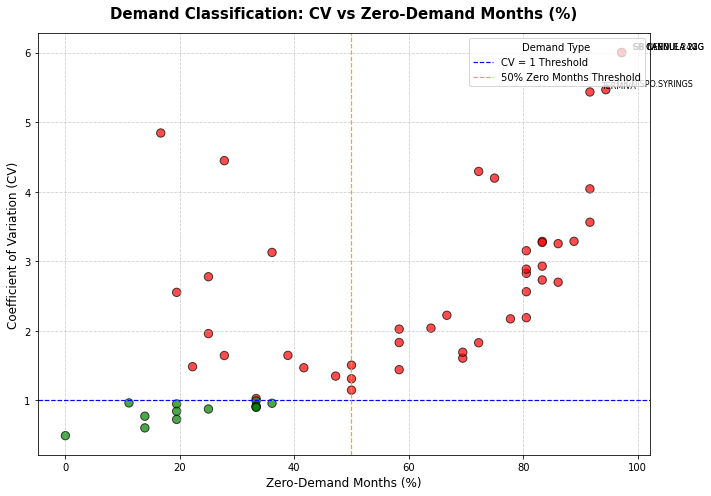

✅ Scatter plot saved as 'Demand_Classification_Scatter.png'


In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your full classification data
df = pd.read_excel("AV_demand_classification.xlsx")

# --- Scatter Plot for Full Dataset ---
plt.figure(figsize=(10, 7))
colors = {'Regular': 'green', 'Intermittent': 'red'}

plt.scatter(df['Zero_Months_%'] * 100, df['CV'],
            c=df['Demand_Type'].map(colors),
            s=70, alpha=0.7, edgecolor='k')

# Threshold lines
plt.axhline(1, color='blue', linestyle='--', linewidth=1.2, label='CV = 1 Threshold')
plt.axvline(50, color='orange', linestyle='--', linewidth=1.2, label='50% Zero Months Threshold')

# Labels & grid
plt.title("Demand Classification: CV vs Zero-Demand Months (%)", fontsize=15, weight='bold', pad=15)
plt.xlabel("Zero-Demand Months (%)", fontsize=12)
plt.ylabel("Coefficient of Variation (CV)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Demand Type", loc='upper right', frameon=True)

# Annotate top 5 variable items
top_points = df.sort_values(by='CV', ascending=False).head(5)
for i, row in top_points.iterrows():
    plt.text(row['Zero_Months_%']*100 + 2, row['CV'] + 0.05, row['Product_Name'], fontsize=8)

plt.tight_layout()
plt.savefig("Demand_Classification_Scatter.png", dpi=200)
plt.show()

print("✅ Scatter plot saved as 'Demand_Classification_Scatter.png'")


##### Code to Create Separate Excel file for Regular & Intermittent Products

In [39]:
import pandas as pd

# Load your main monthly dataset (36 months × 60 items)
monthly = pd.read_excel("AV_monthly_full_with_zeroes_ordered.xlsx")

# Load demand classification (with Demand_Type)
classification = pd.read_excel("AV_demand_classification.xlsx")[["Product_Name", "Demand_Type"]]

# Merge classification into monthly dataset
merged = monthly.merge(classification, on="Product_Name", how="left")

# Split into two subsets
regular_df = merged[merged["Demand_Type"] == "Regular"]
intermittent_df = merged[merged["Demand_Type"] == "Intermittent"]

# Save each as a separate Excel file
regular_df.to_excel("AV_regular_items.xlsx", index=False)
intermittent_df.to_excel("AV_intermittent_items.xlsx", index=False)

print(f" Files created successfully:")
print(f" - Regular items: {regular_df['Product_Name'].nunique()} products")
print(f" - Intermittent items: {intermittent_df['Product_Name'].nunique()} products")


✅ Files created successfully:
 - Regular items: 13 products
 - Intermittent items: 45 products


In [40]:
print(regular_df.groupby("Product_Name")["Quantity"].sum().head())
print(intermittent_df.groupby("Product_Name")["Quantity"].sum().head())


Product_Name
ACCU CHEK ACTIVE     6384
BD SPINAL NEEDLE    21300
DISPOVAN SYR 1ML     2885
DISPOVAN SYR 3ML     4324
DISPOVAN SYR 5ML     3824
Name: Quantity, dtype: int64
Product_Name
ACCUSURE STRIP G       790
ACCUSURE STRIP S      4389
BD EMERALD SYR 3    241776
BD EMERALD SYR.5    125436
BD INSULIN SYR U     15600
Name: Quantity, dtype: int64


##### Forecasting for Regular & Intermittent Products

In [43]:
!pip install statsmodels

  Obtaining dependency information for statsmodels from https://files.pythonhosted.org/packages/fe/7d/3608f14237daccc0f3116b006ee3a42ca0e4dbe296496950624934138171/statsmodels-0.14.5-cp39-cp39-win_amd64.whl.metadata
  Using cached statsmodels-0.14.5-cp39-cp39-win_amd64.whl.metadata (9.8 kB)
Using cached statsmodels-0.14.5-cp39-cp39-win_amd64.whl (9.7 MB)



[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [46]:
# Forecast + Excel workbook export (Regular/Intermittent/ Summary)
# Requirements: pandas, numpy, statsmodels, matplotlib, xlsxwriter
# pip install pandas numpy statsmodels matplotlib xlsxwriter

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# --------- Parameters ----------
forecast_horizon = 12          # number of months to forecast
fixed_window = True            # True -> forecast Apr 2025->Mar 2026; False -> dynamic start after last observed month
fixed_start_date = pd.Timestamp("2025-04-01")  # used if fixed_window True
test_start = pd.Timestamp("2025-01-01")       # Jan-Mar 2025 as test (if available)
out_folder = "forecast_results"
plot_folder = os.path.join(out_folder, "plots")
os.makedirs(out_folder, exist_ok=True)
os.makedirs(plot_folder, exist_ok=True)

# Files (update if needed)
regular_file = "AV_regular_items.xlsx"
intermittent_file = "AV_intermittent_items.xlsx"
workbook_fname = os.path.join(out_folder, "AV_forecasts_workbook_apr2025_mar2026.xlsx")

# --------- Croston implementation ----------
def croston_forecast(y, h=12, alpha=0.1):
    y = np.array(y, dtype=float)
    if len(y) == 0:
        return np.zeros(h)
    nonzero = np.where(y > 0)[0]
    if len(nonzero) == 0:
        return np.zeros(h)
    a_q = y[nonzero[0]]
    a_p = nonzero[0] + 1
    last_nonzero = nonzero[0]
    for t in range(nonzero[0] + 1, len(y)):
        if y[t] > 0:
            interval = t - last_nonzero
            last_nonzero = t
            a_q = alpha * y[t] + (1 - alpha) * a_q
            a_p = alpha * interval + (1 - alpha) * a_p
    fc_val = a_q / a_p if a_p != 0 else 0.0
    return np.repeat(fc_val, h)

def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# --------- Load data ----------
regular_df = pd.read_excel(regular_file)
intermittent_df = pd.read_excel(intermittent_file)

for d in (regular_df, intermittent_df):
    d['Month'] = pd.to_datetime(d['Month'])
    d.sort_values(['Product_Name','Month'], inplace=True)

products_regular = sorted(regular_df['Product_Name'].unique())
products_intermittent = sorted(intermittent_df['Product_Name'].unique())

import re
# -------------------
# sanitize filename helper
def sanitize_filename(name, max_length=120):
    # Replace invalid Windows filename chars with underscore
    # and also collapse repeated underscores and trim whitespace
    invalid_chars = r'[<>:"/\\|?*\x00-\x1f]'          # includes control chars
    name = re.sub(invalid_chars, '_', name)
    # remove any remaining leading/trailing whitespace or dots
    name = name.strip().strip('.')
    # collapse multiple underscores
    name = re.sub(r'__+', '_', name)
    # limit length
    if len(name) > max_length:
        name = name[:max_length]
    return name

# containers
rows_regular = []
rows_intermittent = []
summary_rows = []

# helper function
def forecast_product_and_store(prod_name, df_prod, is_intermittent):
    dfp = df_prod.set_index('Month').sort_index()
    qty = dfp['Quantity'].astype(float)

    # train/test split
    train = qty[qty.index < test_start]
    test = qty[(qty.index >= test_start) & (qty.index < test_start + pd.DateOffset(months=3))]

    # choose model & forecast
    model_used = None
    try:
        if is_intermittent:
            model_used = "Croston"
            fc = croston_forecast(train.values, h=forecast_horizon, alpha=0.2)
            test_fc = croston_forecast(train.values, h=len(test), alpha=0.2) if len(test)>0 else np.array([])
        else:
            model_used = "HoltWinters"
            if len(train) < 12 or train.sum() == 0 or train.std() == 0:
                mean_val = train.mean() if len(train)>0 else 0.0
                fc = np.repeat(mean_val, forecast_horizon)
                test_fc = np.repeat(mean_val, len(test))
            else:
                hw = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12, initialization_method="estimated")
                hw_fit = hw.fit(optimized=True)
                fc = hw_fit.forecast(forecast_horizon)
                test_fc = hw_fit.forecast(len(test)) if len(test)>0 else np.array([])
    except Exception as e:
        # fallback to mean
        model_used = f"Fallback_mean_due_error"
        mean_val = train.mean() if len(train)>0 else 0.0
        fc = np.repeat(mean_val, forecast_horizon)
        test_fc = np.repeat(mean_val, len(test))

    # mape on Jan-Mar 2025 if available
    mape_score = mape(test.values if len(test)>0 else np.array([]), test_fc) if len(test)>0 else np.nan

    # determine forecast index
    if fixed_window:
        fc_index = pd.date_range(start=fixed_start_date, periods=forecast_horizon, freq='MS')
    else:
        last_obs = dfp.index.max() if len(dfp.index)>0 else pd.Timestamp('2025-03-01')
        start_month = (last_obs + pd.DateOffset(months=1)).replace(day=1)
        fc_index = pd.date_range(start=start_month, periods=forecast_horizon, freq='MS')

    fc_vals = np.array(fc, dtype=float).flatten()
    if len(fc_vals) < forecast_horizon:
        fc_vals = np.pad(fc_vals, (0, forecast_horizon - len(fc_vals)), constant_values=0.0)

    # use last known Avg_Rate to compute amounts
    last_rate = np.nan
    if 'Avg_Rate' in dfp.columns:
        lr = dfp['Avg_Rate'].ffill().bfill()
        if len(lr)>0:
            last_rate = float(lr.iloc[-1])
    fc_amounts = [ (q * last_rate) if not np.isnan(last_rate) else np.nan for q in fc_vals ]

    # store rows
    for dt, qv, av in zip(fc_index, fc_vals, fc_amounts):
        row = {
            'Product_Name': prod_name,
            'Forecast_Month': dt,
            'Forecast_Quantity': float(qv),
            'Avg_Rate_used': float(last_rate) if not np.isnan(last_rate) else np.nan,
            'Forecast_Amount': float(av) if not np.isnan(av) else np.nan,
            'Model': model_used
        }
        if is_intermittent:
            rows_intermittent.append(row)
        else:
            rows_regular.append(row)

    # summary row
    summary_rows.append({
        'Product_Name': prod_name,
        'Model': model_used,
        'MAPE_test_JanMar2025': mape_score,
        'Mean_train_qty': float(train.mean()) if len(train)>0 else 0.0,
        'Zero_rate_train': float((train==0).sum()/len(train)) if len(train)>0 else 1.0,
        'Sum_forecast_next12': float(np.sum(fc_vals))
    })

        # --------- Plot history/test/forecast (robust: convert to 1-D numpy / python datetimes) ----------
    plt.figure(figsize=(9,3.6))

    # prepare numeric / datetime-safe arrays
    # TRAIN
    if len(train) > 0:
        x_train = pd.to_datetime(train.index).to_pydatetime()   # array of python datetimes
        y_train = train.values.astype(float)                    # 1-D numpy array
        plt.plot(x_train, y_train, label='Train', marker='o')

    # TEST
    if len(test) > 0:
        x_test = pd.to_datetime(test.index).to_pydatetime()
        y_test = test.values.astype(float)
        plt.plot(x_test, y_test, label='Test', marker='o')

    # FORECAST: fc_index is already a DatetimeIndex (or created via pd.date_range)
    x_fc = pd.to_datetime(fc_index).to_pydatetime()
    y_fc = np.array(fc_vals, dtype=float).flatten()
    plt.plot(x_fc, y_fc, linestyle='--', marker='o', label='Forecast')

    plt.title(f"{prod_name} | {model_used} | MAPE={np.round(mape_score,2) if not np.isnan(mape_score) else 'NA'}")
    plt.xlabel("Month")
    plt.ylabel("Quantity")
    plt.legend(loc='upper left', fontsize=8)
    plt.tight_layout()

    # Use it before saving
    safe_name = sanitize_filename(prod_name.replace(' ', '_'))
    fname = os.path.join(plot_folder, f"{safe_name}_forecast_12m.png")
    plt.savefig(fname, dpi=140)
    plt.close()
    # -------------------


# --------- Run forecasts for all products ----------
for p in products_regular:
    dfp = regular_df[regular_df['Product_Name'] == p].copy()
    forecast_product_and_store(p, dfp, is_intermittent=False)

for p in products_intermittent:
    dfp = intermittent_df[intermittent_df['Product_Name'] == p].copy()
    forecast_product_and_store(p, dfp, is_intermittent=True)

# --------- Create DataFrames and save to Excel workbook ----------
df_reg_fc = pd.DataFrame(rows_regular)
df_int_fc = pd.DataFrame(rows_intermittent)
df_summary = pd.DataFrame(summary_rows).sort_values('Product_Name')

# Ensure Forecast_Month is datetime
for dfc in (df_reg_fc, df_int_fc):
    if not dfc.empty:
        dfc['Forecast_Month'] = pd.to_datetime(dfc['Forecast_Month'])

# Save workbook with three sheets
with pd.ExcelWriter(workbook_fname, engine='xlsxwriter', datetime_format='yyyy-mm-dd') as writer:
    df_reg_fc.to_excel(writer, sheet_name='Regular_forecasts', index=False)
    df_int_fc.to_excel(writer, sheet_name='Intermittent_forecasts', index=False)
    df_summary.to_excel(writer, sheet_name='Summary', index=False)

print("Workbook saved:", workbook_fname)
print(" - Plots saved in:", plot_folder)
print(" - Regular forecasts rows:", len(df_reg_fc))
print(" - Intermittent forecasts rows:", len(df_int_fc))
print(" - Summary rows:", len(df_summary))


c:\users\pranj\appdata\local\programs\python\python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\users\pranj\appdata\local\programs\python\python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\users\pranj\appdata\local\programs\python\python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\users\pranj\appdata\local\programs\python\python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\users\pranj\appdata\local\programs\python\python39\lib\si

✅ Workbook saved: forecast_results\AV_forecasts_workbook_apr2025_mar2026.xlsx
 - Plots saved in: forecast_results\plots
 - Regular forecasts rows: 156
 - Intermittent forecasts rows: 540
 - Summary rows: 58


##### Replacing  the flat forecasts from Croston Method with realistic 0/nonzero month allocations — while keeping totals same.

In [47]:
import pandas as pd
import numpy as np
import math

def postprocess_intermit_forecast(forecast_df, full_history_df, horizon_months=12):
    """
    Convert flat Croston forecasts into realistic 0/nonzero month allocations.

    Parameters
    ----------
    forecast_df : pd.DataFrame
        Forecast data (e.g., from 'Intermittent_forecasts' sheet) 
        Must include: ['Product_Name', 'Forecast_Month', 'Forecast_Quantity', 'Avg_Rate_used']
        
    full_history_df : pd.DataFrame
        Full monthly history (e.g., AV_monthly_full_with_zeroes_ordered.xlsx)
        Must include: ['Product_Name', 'Month', 'Quantity']
        
    horizon_months : int, optional (default=12)
        Number of months in the forecast horizon.
        
    Returns
    -------
    pd.DataFrame
        Post-processed forecast with:
        ['Product_Name', 'Forecast_Month', 'Post_Forecast_Quantity', 'Avg_Rate_used', 'Post_Forecast_Amount']
    """

    # Ensure datetime
    forecast_df = forecast_df.copy()
    forecast_df['Forecast_Month'] = pd.to_datetime(forecast_df['Forecast_Month'], errors='coerce')
    full_history_df = full_history_df.copy()
    full_history_df['Month'] = pd.to_datetime(full_history_df['Month'], errors='coerce')

    # Compute historical probability of nonzero demand per product
    hist_info = {}
    for prod, g in full_history_df.groupby('Product_Name'):
        total_months = len(g)
        nonzero_count = (g['Quantity'].fillna(0) > 0).sum()
        prob_nonzero = nonzero_count / total_months if total_months > 0 else 0.0

        # month-of-year pattern
        g['moy'] = g['Month'].dt.month
        moy_counts = g.groupby('moy').apply(lambda x: (x['Quantity'].fillna(0) > 0).sum())
        moy_counts = moy_counts.reindex(range(1,13), fill_value=0)
        moy_prop = moy_counts / moy_counts.sum() if moy_counts.sum() > 0 else pd.Series(0, index=range(1,13))

        hist_info[prod] = {
            'prob_nonzero': prob_nonzero,
            'moy_prop': moy_prop
        }

    # Process each product forecast
    post_rows = []
    for prod, g in forecast_df.groupby('Product_Name'):
        g = g.sort_values('Forecast_Month')
        fc_months = list(g['Forecast_Month'])
        horizon = len(fc_months)
        total_forecast = g['Forecast_Quantity'].astype(float).sum()
        avg_rate = g['Avg_Rate_used'].astype(float).iloc[0] if 'Avg_Rate_used' in g.columns else np.nan

        info = hist_info.get(prod, {'prob_nonzero': 0.0, 'moy_prop': pd.Series(0, index=range(1,13))})
        prob_nonzero = info['prob_nonzero']
        moy_prop = info['moy_prop']

        # determine how many months should get nonzero forecast
        n_nonzero = int(round(prob_nonzero * horizon))
        if n_nonzero == 0 and prob_nonzero > 0 and total_forecast > 0:
            n_nonzero = 1

        if total_forecast == 0 or n_nonzero == 0:
            for dt in fc_months:
                post_rows.append({
                    'Product_Name': prod,
                    'Forecast_Month': pd.to_datetime(dt),
                    'Post_Forecast_Quantity': 0.0,
                    'Avg_Rate_used': float(avg_rate) if not pd.isna(avg_rate) else np.nan,
                    'Post_Forecast_Amount': 0.0
                })
            continue

        # assign months based on month-of-year probability if available
        month_scores = []
        for dt in fc_months:
            moy = pd.to_datetime(dt).month
            score = moy_prop.get(moy, 0.0) if isinstance(moy_prop, pd.Series) else 0.0
            month_scores.append((dt, score))

        # If no seasonality, pick evenly spaced months
        if sum(s for _, s in month_scores) == 0:
            indices = np.linspace(0, horizon - 1, n_nonzero, dtype=int)
            chosen = [fc_months[i] for i in indices]
        else:
            month_scores_sorted = sorted(month_scores, key=lambda x: (x[1], -pd.to_datetime(x[0]).toordinal()), reverse=True)
            chosen = [t[0] for t in month_scores_sorted[:n_nonzero]]

        # allocate total forecast evenly
        base_qty = int(math.floor(total_forecast / n_nonzero))
        allocations = [base_qty] * n_nonzero
        remainder = int(round(total_forecast - base_qty * n_nonzero))
        for i in range(remainder):
            allocations[i] += 1

        chosen_sorted = sorted(chosen)
        alloc_map = {chosen_sorted[i]: allocations[i] for i in range(len(chosen_sorted))}

        # populate postprocessed rows
        for dt in fc_months:
            q_alloc = float(alloc_map.get(dt, 0.0))
            amt = q_alloc * avg_rate if not pd.isna(avg_rate) else np.nan
            post_rows.append({
                'Product_Name': prod,
                'Forecast_Month': pd.to_datetime(dt),
                'Post_Forecast_Quantity': q_alloc,
                'Avg_Rate_used': float(avg_rate) if not pd.isna(avg_rate) else np.nan,
                'Post_Forecast_Amount': float(amt) if not pd.isna(amt) else np.nan
            })

    post_df = pd.DataFrame(post_rows)
    post_df = post_df.sort_values(['Product_Name','Forecast_Month']).reset_index(drop=True)
    return post_df


In [49]:
# Load your data
wb = pd.read_excel(r"D:\D.S. Programme\BDM Project\My Project\Analysis\Forecasting\forecast_results\AV_forecasts_workbook_apr2025_mar2026.xlsx", sheet_name=None)
inter_fc = wb["Intermittent_forecasts"]
hist = pd.read_excel("AV_monthly_full_with_zeroes_ordered.xlsx")

# Generate post-processed version
post_df = postprocess_intermit_forecast(inter_fc, hist, horizon_months=12)

# Save it
post_df.to_excel("AV_intermittent_postprocessed.xlsx", index=False)
print("✅ Saved realistic post-processed intermittent forecasts!")


✅ Saved realistic post-processed intermittent forecasts!
